# *RNR1* Gene expression and chromatin deconvolution 

Now that we have settled on the VST transformation and fixed the CLOCCS parameters, the deconvolution for RNR1 seems stable. 

There is uncertainty with the combined model, but we can at least start looking at the chromatin deconvolutions in conjuction with the gene expression.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [69]:
from src.config import load_combined_yl_vst_gene_expression_config
from src.model import Model

def plot_and_save_model_config(gene_name, config, model_name, abbreviated=False,
                              gamma=0):
    model = Model(config, gene_name, gamma)
    model.deconvolve()
    model.plot_deconvolved_gene(abbreviated=abbreviated)
    plt.savefig(f'{save_dir}/{gene_name}_{model_name}.png', dpi=150)
    return model

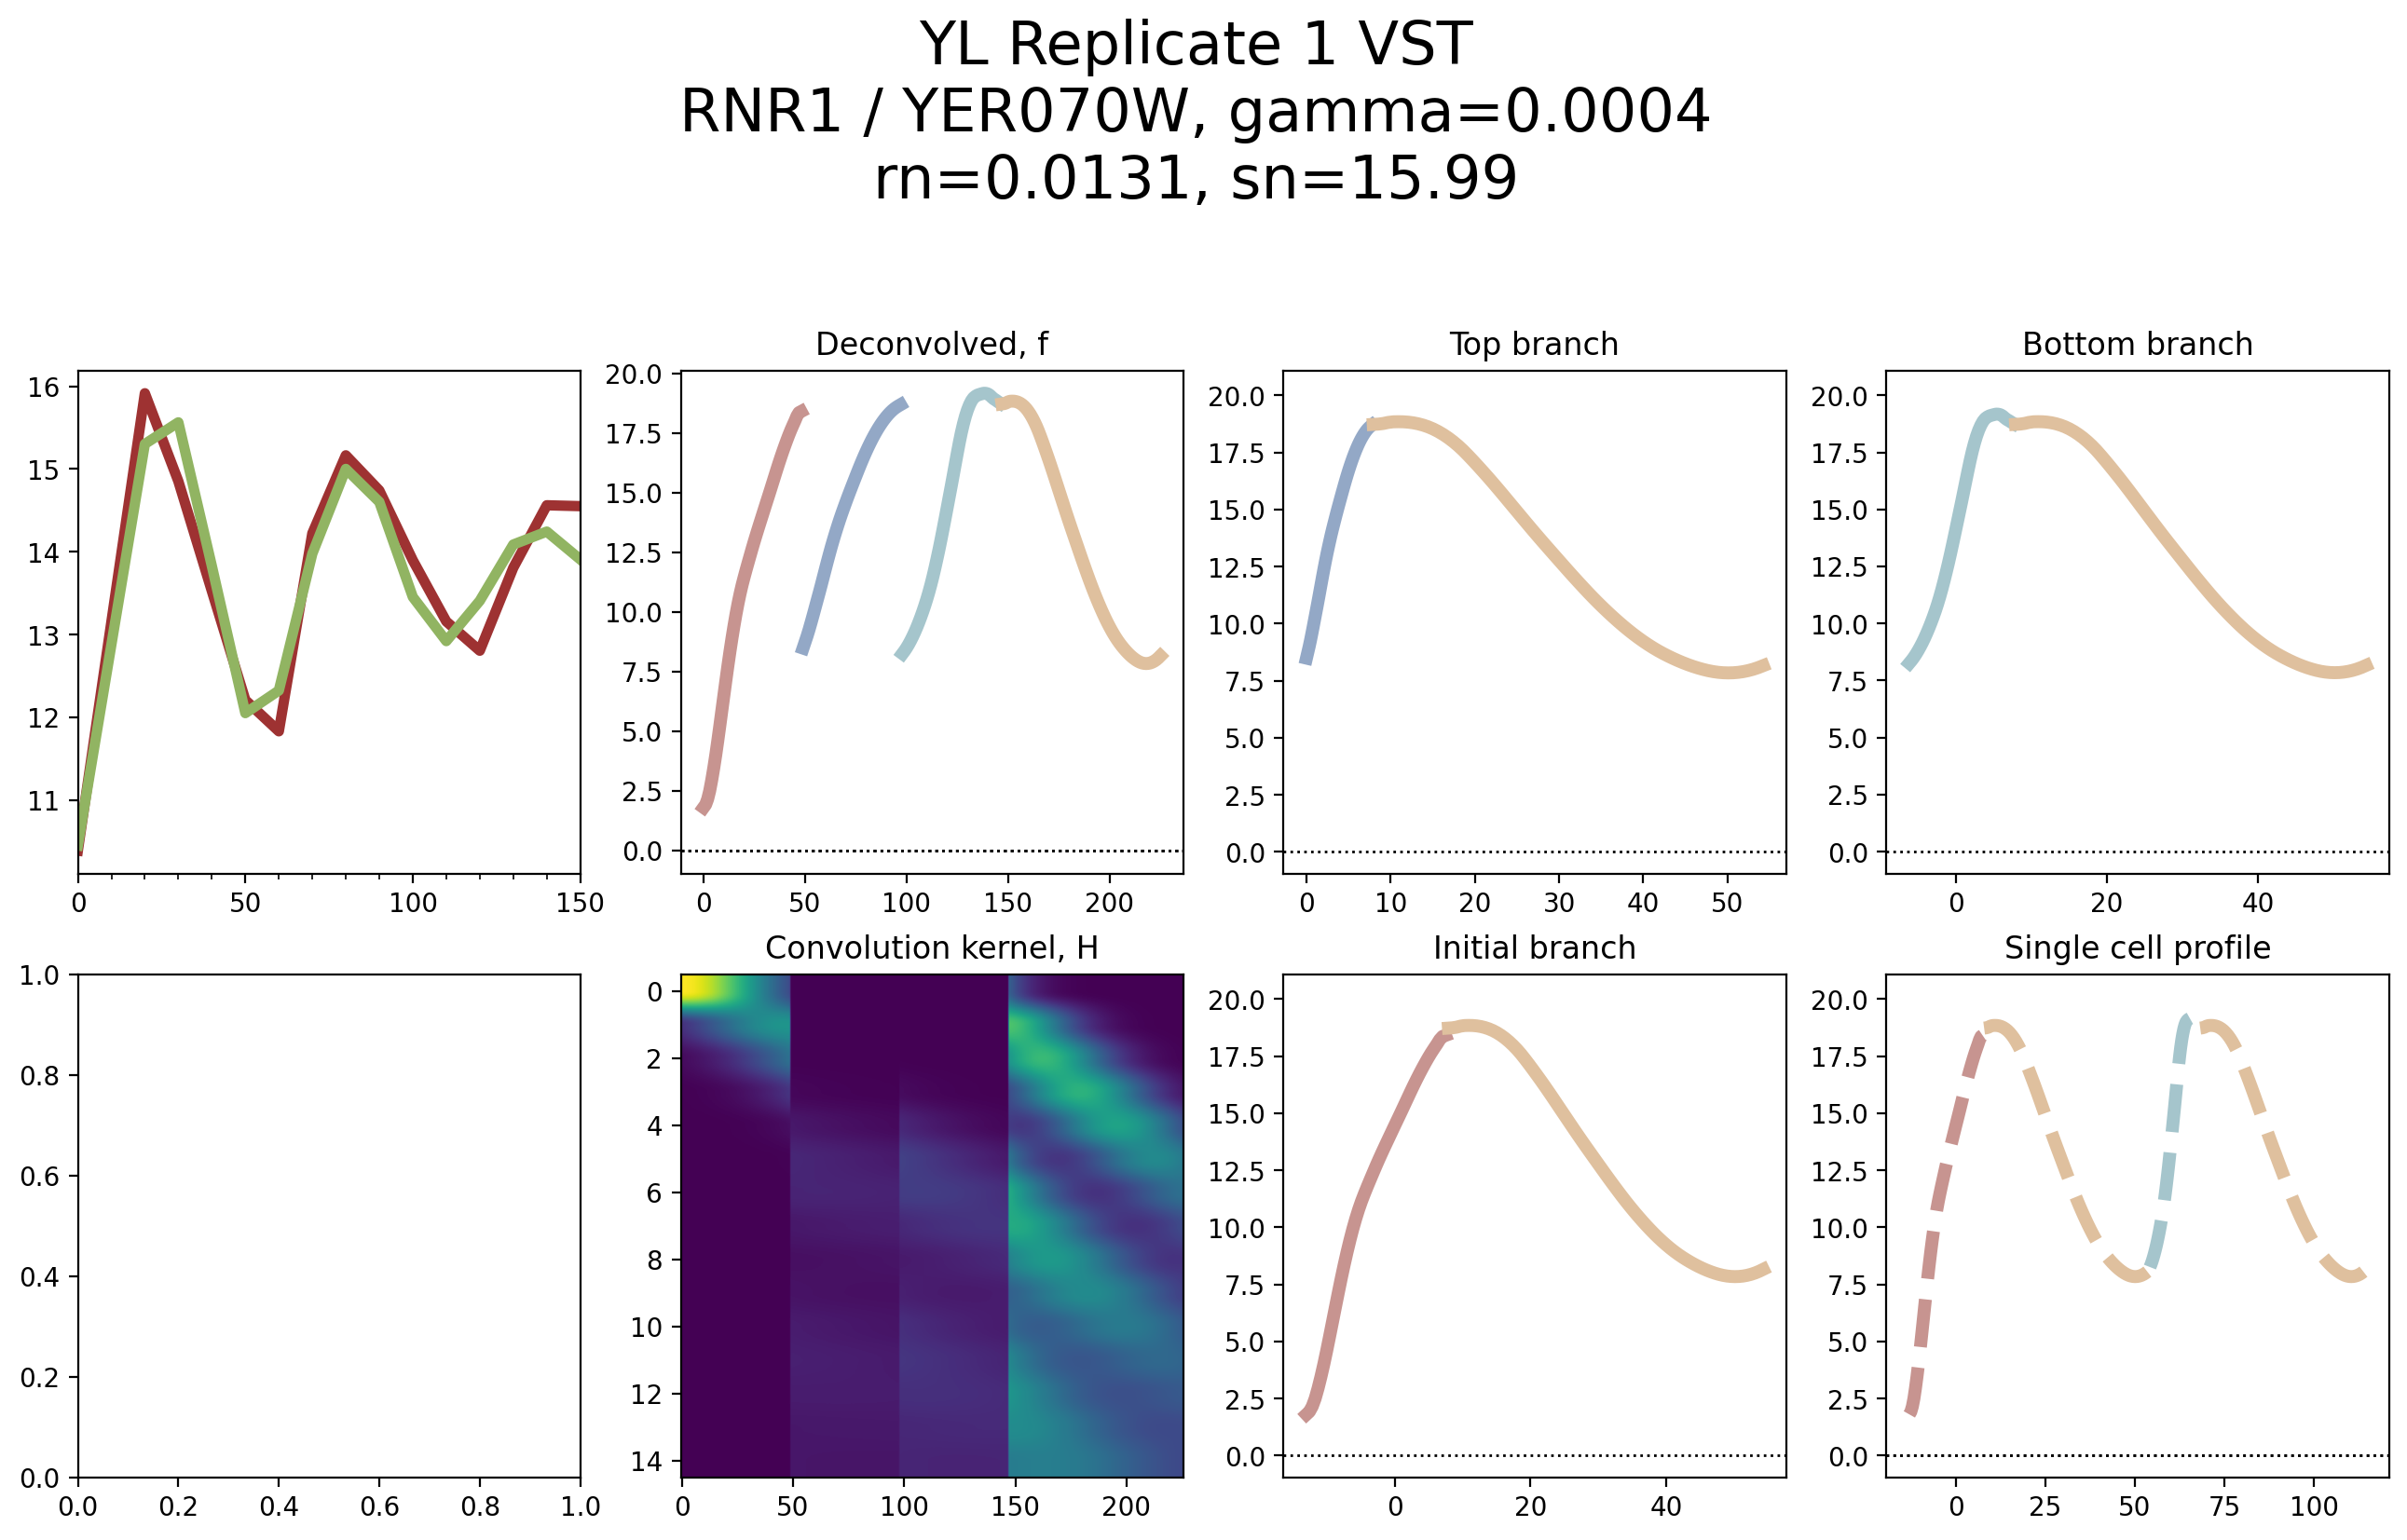

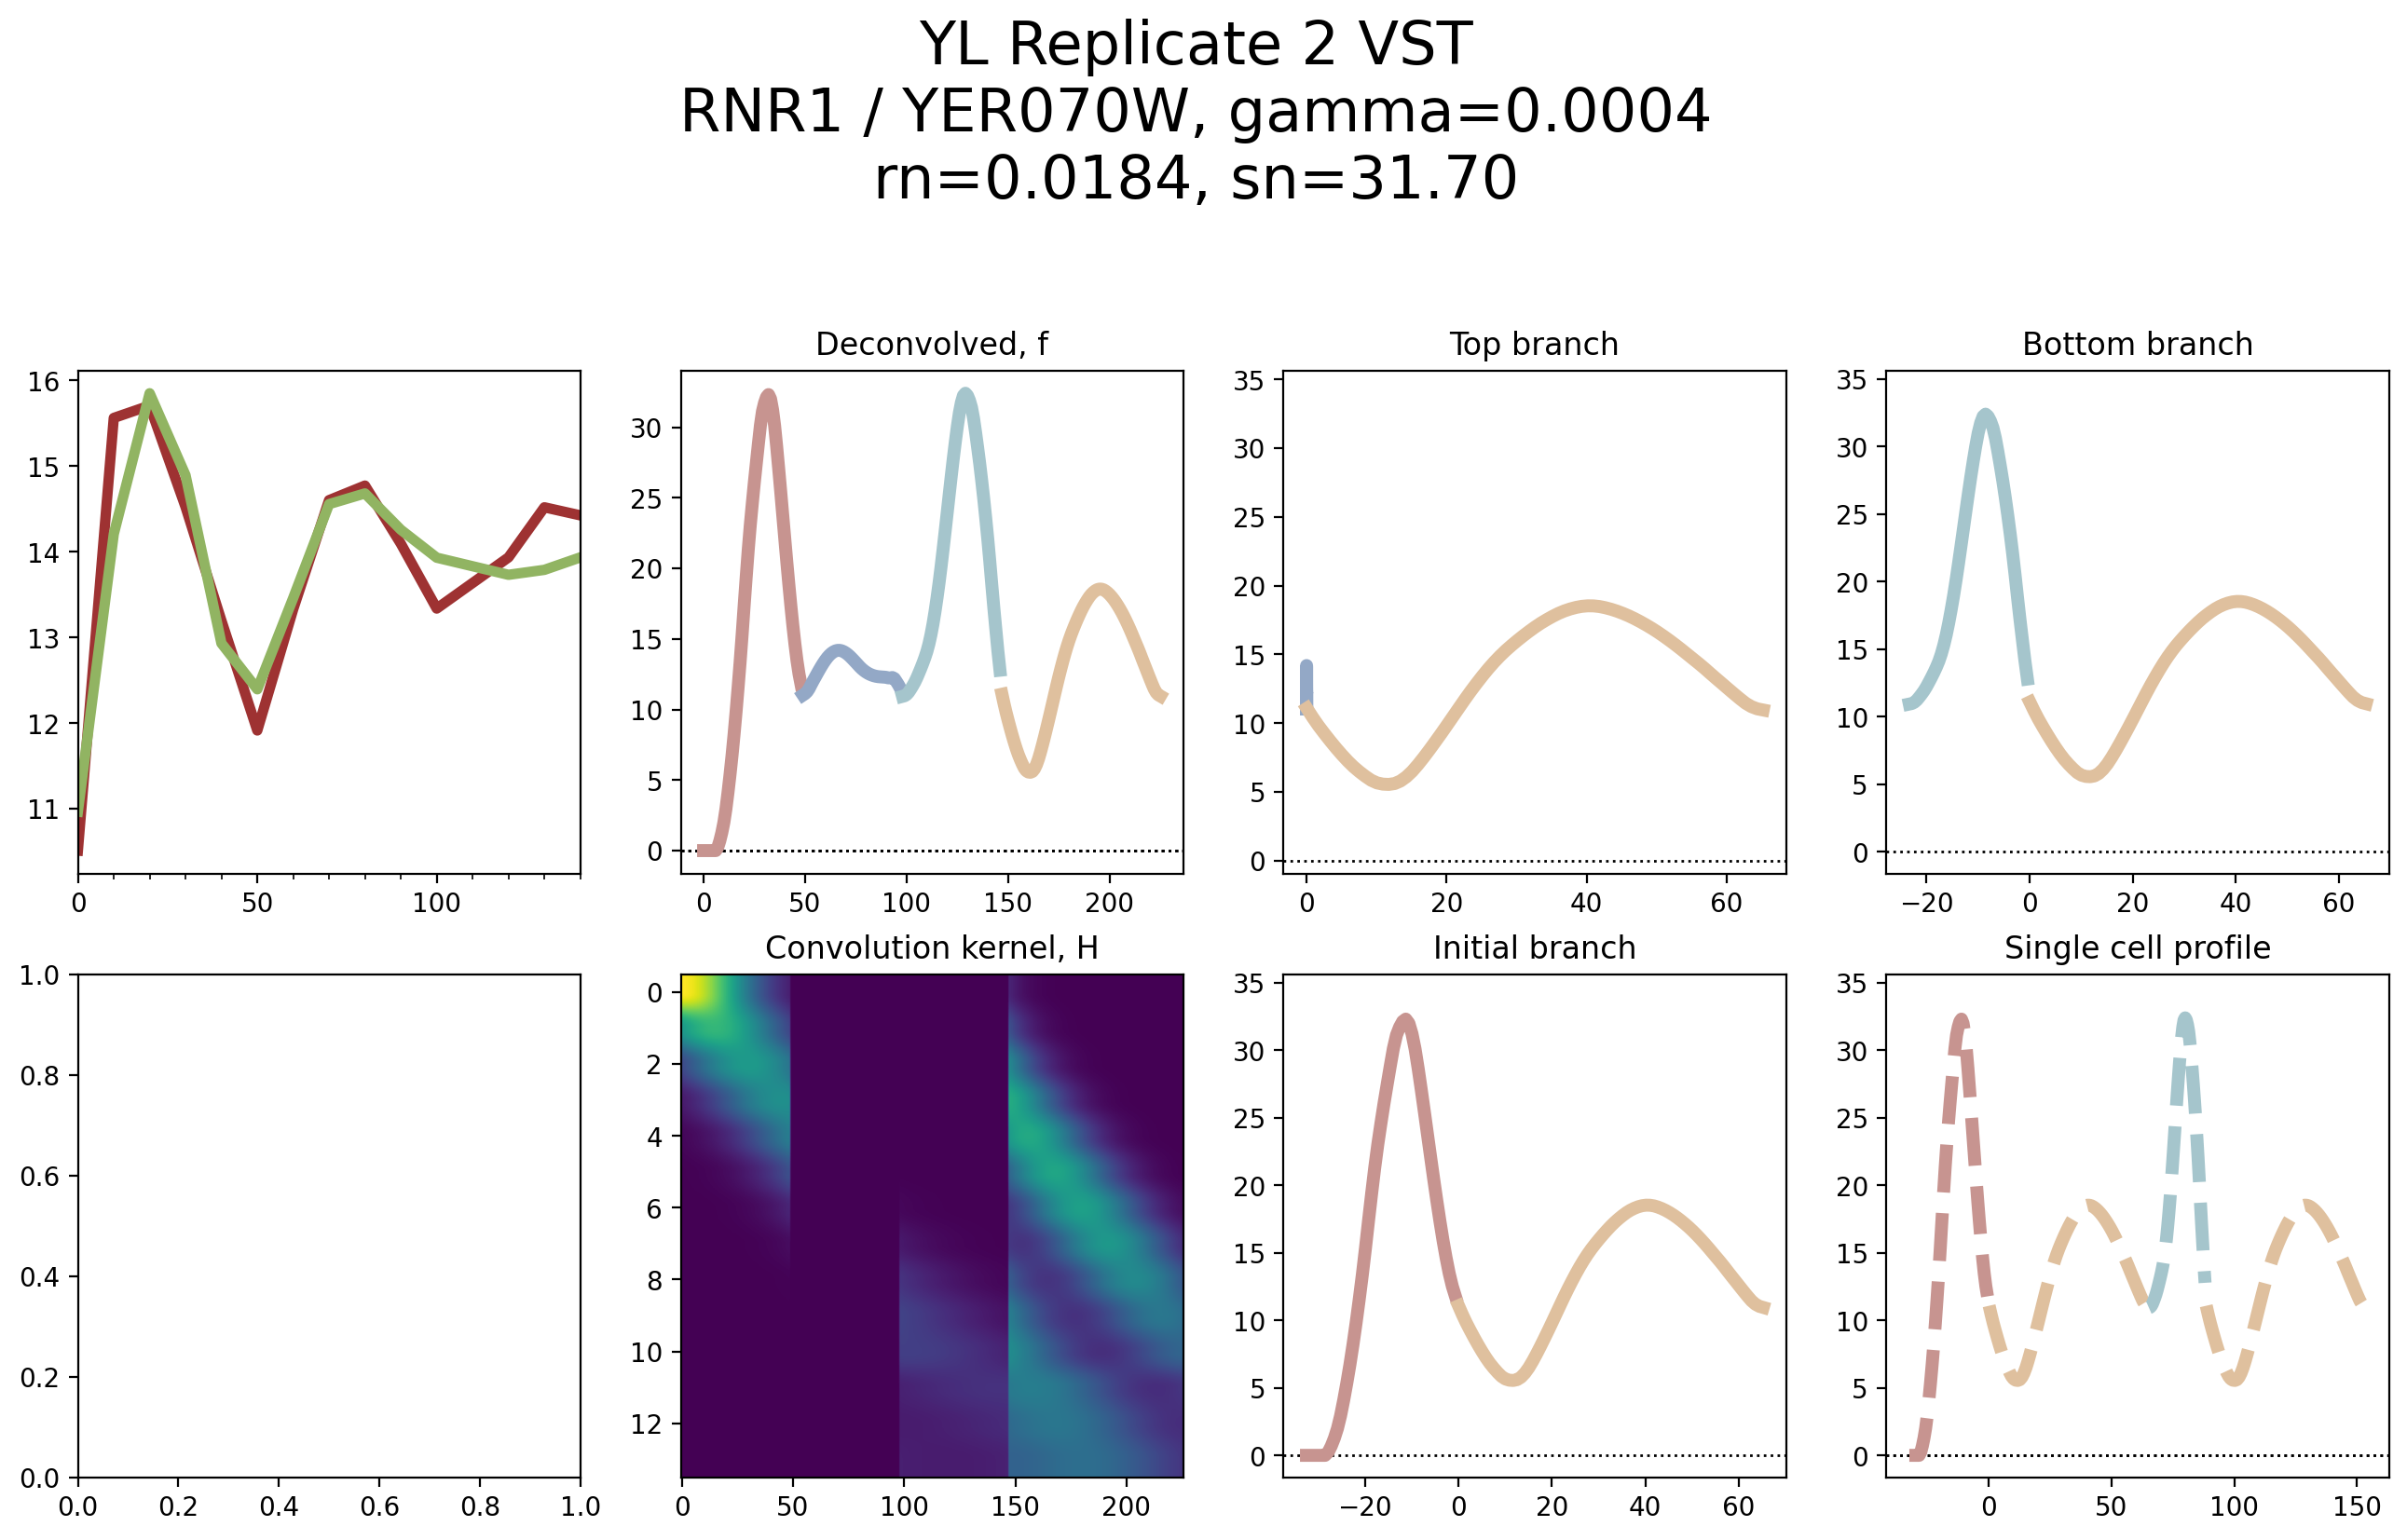

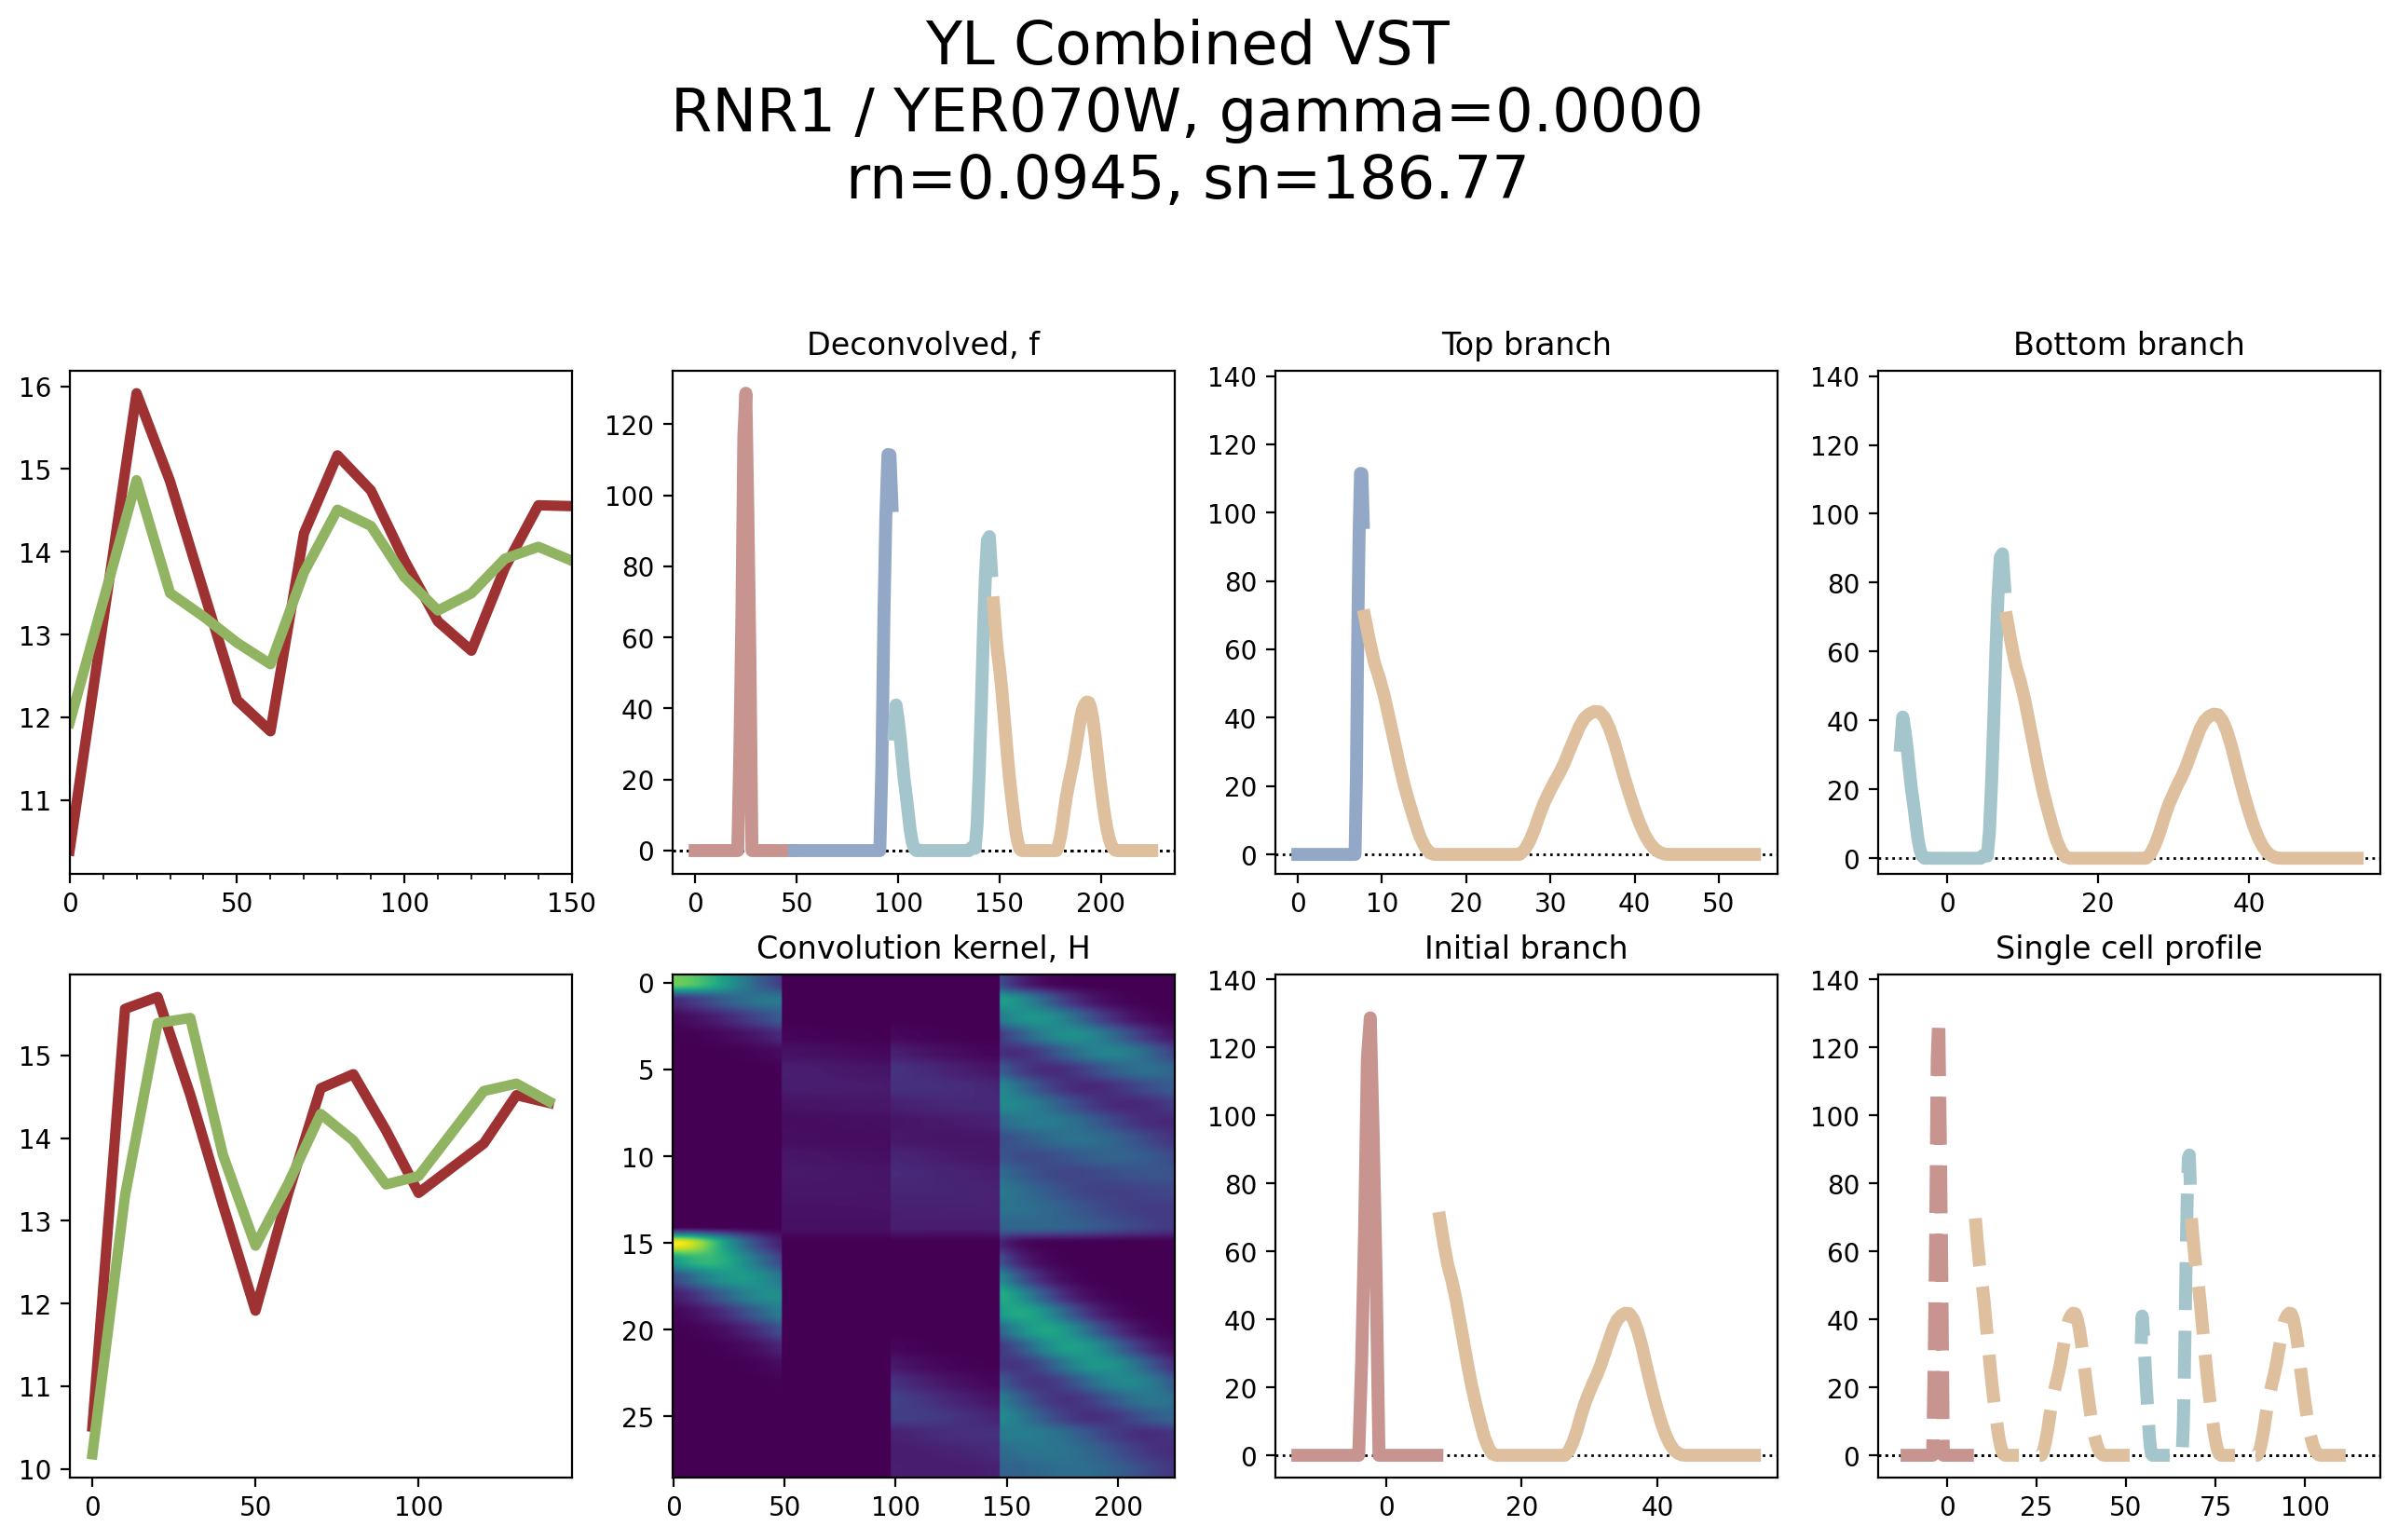

In [79]:
from src.config import load_yl_replicate1_rg1_vst_config, load_yl_replicate2_rg1_vst_config

save_dir = 'output/positive_controls/comparison_rep1_vs_rep2_vs_combined'

config1 = load_yl_replicate1_rg1_vst_config()
config_combined = load_combined_yl_vst_gene_expression_config()
config2 = load_yl_replicate2_rg1_vst_config()

ge_model1 = plot_and_save_model_config('RNR1', config1, 'Replicate 1', 
                                       gamma=0.0004)
ge_model2 = plot_and_save_model_config('RNR1', config2, 'Replicate 2',
                                       gamma=0.0004)
ge_model_combined = plot_and_save_model_config('RNR1', config_combined, 
                                               'Combined', gamma=0.00001)


In [74]:
# ge_model1 = plot_and_save_model_config('RNR3', config1, 'Replicate 1', abbreviated=True)
# ge_model2 = plot_and_save_model_config('RNR3', config2, 'Replicate 2', abbreviated=True)



In [73]:
# ge_model1 = plot_and_save_model_config('FIG1', config1, 'Replicate 1', abbreviated=True, 
#                                        gamma=0.001)
# ge_model2 = plot_and_save_model_config('FIG1', config2, 'Replicate 2', abbreviated=True,
#                                       gamma=0.001)



In [13]:
from src.config import load_yl_replicate2_rg1_chromatin_config, \
    load_yl_replicate1_rg1_chromatin_config
from cc_src.chromatin_grid_compute import ChromatinGrid
from src.deconvolution_plotter import DeconvolutionPlotter
from src.deconvolve_chromatin import deconvolve_chromatin

def deconvolve_chrom_gene(chrom1_config, genename, gamma, replicate):
    chrom1_model = Model(chrom1_config, genename, gamma)

    chromatin_gridder = ChromatinGrid()
    chromatin_gridder.set_gene(chrom1_model.orf_name, replicate=replicate)
    chromatin_gridder.create_bins_per_all_sample()
    chromatin_gridder.create_deconvolution_matrices()
    f = deconvolve_chromatin(chrom1_model, chromatin_gridder.deconv_hist)
    return chrom1_model, chromatin_gridder


In [17]:
from src.config import load_yl_replicate1_rg1_chromatin_config
from src.deconvolve_chromatin import deconvolve_chromatin

# Deconvolve the chromatin of replicate 1
chrom1_config = load_yl_replicate1_rg1_chromatin_config()

genename = 'RNR1'
gamma = 0.0001

chrom1_model = Model(chrom1_config, genename, gamma)
chrom1_gridder = ChromatinGrid()
chrom1_gridder.set_gene(chrom1_model.orf_name, replicate=replicate)
chrom1_gridder.create_bins_per_all_sample()
chrom1_gridder.create_deconvolution_matrices()

In [20]:
ge_model1 = Model(config1, 'RNR1', 0.0001)
ge_model1.deconvolve()


In [25]:
chrom1_model.gamma = 0

In [63]:
f = deconvolve_chromatin(chrom1_model, chrom1_gridder.deconv_hist, allow_negative=True)
plotter = DeconvolutionPlotter(ge_model1, chrom1_gridder, chrom1_model)
#plotter.plot_deconvolved_models()

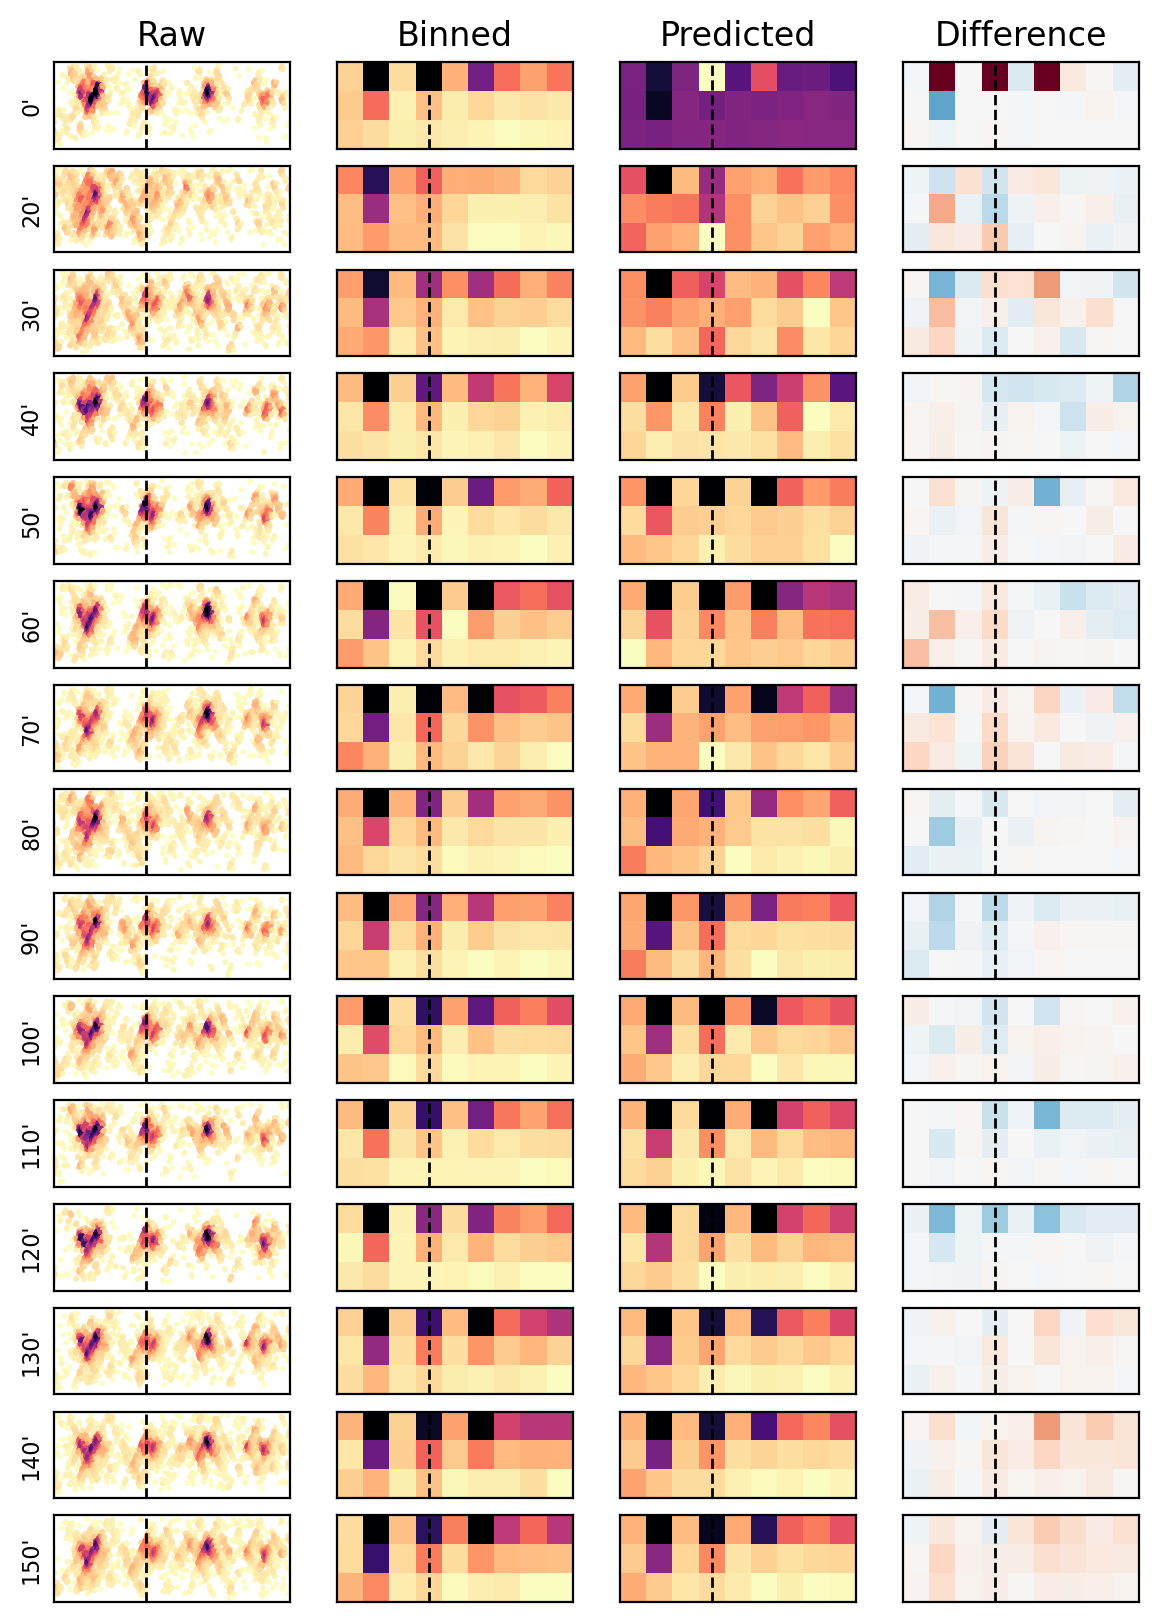

In [64]:
chrom1_gridder.plot_prediction_comparison(chrom1_model)

In [65]:
g_img = chrom1_gridder.deconv_hist.reshape(-1, 3, 9)
f_img = chrom1_model.f.reshape(-1, 3, 9)

def plot_r_c_fit(r, c):
    f_dat = f_img[:, r, c]
    g_dat = g_img[:, r, c]
    pred_g = np.matmul(chrom1_model.H, f_img[:, r, c])
    plt.plot(g_dat)
    plt.plot(pred_g)    

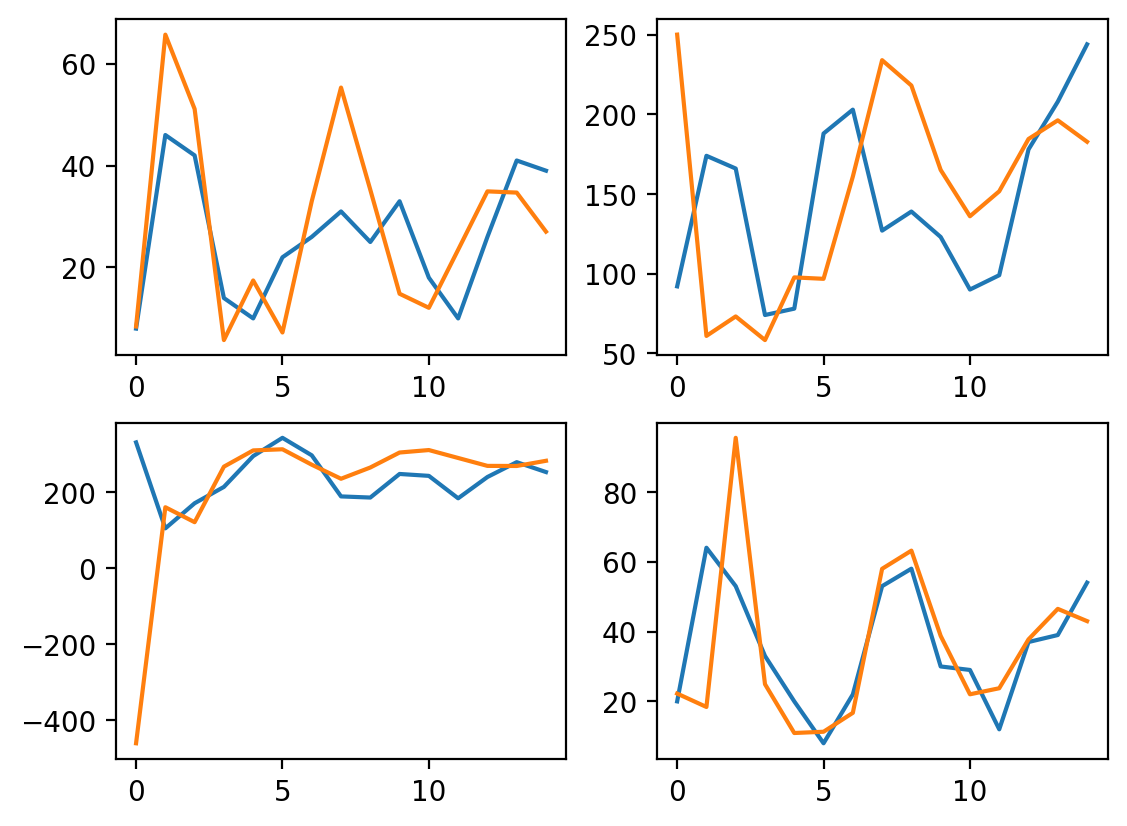

In [66]:
plt.subplot(2, 2, 1)
plot_r_c_fit(1, 2)

plt.subplot(2, 2, 2)
plot_r_c_fit(1, 1)

plt.subplot(2, 2, 3)
plot_r_c_fit(2, 3)

plt.subplot(2, 2, 4)
plot_r_c_fit(2, 2)